In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
import numpy as np

In [3]:
df = pd.read_csv("/Volumes/KINGSTON/data/phd/image-analysis/synapse-counting/VCAM1/VCAM1-LacZ_VGLUT1-PSD95_output_data/results.csv")
df.columns

Index(['Unnamed: 0', 'img_filename', 'overlap_um2', 'overlap_um2_rot',
       'pearson_cor', 'pvalue', 'pearson_cor_rot', 'pvalue_rot',
       'overlap_coeff', 'overlap_coeff_rot', 'presynapse_threshold',
       'postsynapse_threshold', 'presynapse_image_mfi',
       'postsynapse_image_mfi', 'pre_puncta_density_per_100_um2',
       'post_puncta_density_per_100_um2', 'pre_staining_area_um2',
       'post_staining_area_um2', 'pre_mean_puncta_size_um2',
       'post_mean_puncta_size_um2', 'gRNA', 'hippocampal_layer'],
      dtype='object')

In [4]:
# adding a brain column to the dataframe
df['Brain'] = df['img_filename'].str.split('_').str[2]

In [5]:
def check_statistics(df, hippocampal_layer, metric, candidate_gRNA, control_gRNA = "LacZ-gRNA"):
    filtered_df_hip_layer = df[df["hippocampal_layer"].str.contains(hippocampal_layer)]
    ReplicateAverages = filtered_df_hip_layer.groupby(["gRNA","Brain"], as_index=False).agg({metric:"mean"})
    ReplicateAveragesPivot = ReplicateAverages.pivot_table(columns="gRNA", values=metric, index="Brain")
    statistic, pvalue = scipy.stats.ttest_rel(ReplicateAveragesPivot[control_gRNA], ReplicateAveragesPivot[candidate_gRNA])
    
    return filtered_df_hip_layer, ReplicateAveragesPivot, ReplicateAverages, statistic, pvalue

In [6]:
_ , table, _ , _ , p_value = check_statistics(df, hippocampal_layer = "CA3 SL", metric = "presynapse_image_mfi", candidate_gRNA = "VCAM1-gRNA")
p_value

0.011440825772768679

In [7]:
hippocampal_layers  =  ["CA1 SLM", "CA1 SR", "CA1 SO", "CA3 SO", "CA3 SL", "CA3 SR", "DG ML", "DG Hilus"]
metrics = ["overlap_um2", "pearson_cor", "overlap_coeff", "presynapse_image_mfi", "postsynapse_image_mfi", "pre_puncta_density_per_100_um2", "post_puncta_density_per_100_um2", "pre_staining_area_um2", "post_staining_area_um2", "pre_mean_puncta_size_um2", "post_mean_puncta_size_um2"]

statistics_results = []

for hippocampal_layer in hippocampal_layers:
    for metric in metrics:
        _ , table, _ , _ , p_value = check_statistics(df, hippocampal_layer = hippocampal_layer, metric = metric, candidate_gRNA = "VCAM1-gRNA")
        statistics_results.append({"hippocampal_layer": hippocampal_layer, "metric": metric, "p_value": p_value})

df_statistics_results = pd.DataFrame(statistics_results)  # create dataFrame from list
print(df_statistics_results)

   hippocampal_layer                           metric   p_value
0            CA1 SLM                      overlap_um2  0.357073
1            CA1 SLM                      pearson_cor  0.791739
2            CA1 SLM                    overlap_coeff  0.481896
3            CA1 SLM             presynapse_image_mfi  0.962370
4            CA1 SLM            postsynapse_image_mfi  0.897151
..               ...                              ...       ...
83          DG Hilus  post_puncta_density_per_100_um2  0.950039
84          DG Hilus            pre_staining_area_um2  0.665412
85          DG Hilus           post_staining_area_um2  0.915346
86          DG Hilus         pre_mean_puncta_size_um2  0.887264
87          DG Hilus        post_mean_puncta_size_um2  0.818562

[88 rows x 3 columns]


In [8]:
p_value_threshold = 0.05  # Set your desired p-value threshold
filtered_df = df_statistics_results[df_statistics_results["p_value"] <= p_value_threshold]

# Print the filtered DataFrame
print(filtered_df)

   hippocampal_layer                     metric   p_value
25            CA1 SO       presynapse_image_mfi  0.036487
33            CA3 SO                overlap_um2  0.026188
35            CA3 SO              overlap_coeff  0.000415
36            CA3 SO       presynapse_image_mfi  0.022510
37            CA3 SO      postsynapse_image_mfi  0.023217
41            CA3 SO     post_staining_area_um2  0.048587
42            CA3 SO   pre_mean_puncta_size_um2  0.031116
43            CA3 SO  post_mean_puncta_size_um2  0.026330
47            CA3 SL       presynapse_image_mfi  0.011441
58            CA3 SR       presynapse_image_mfi  0.000840


In [9]:
df_filtered , table, df_averages , _ , p_value = check_statistics(df, hippocampal_layer = "CA3 SL", metric = "presynapse_image_mfi", candidate_gRNA = "VCAM1-gRNA")
df_filtered

,Unnamed: 0,img_filename,overlap_um2,overlap_um2_rot,pearson_cor,pvalue,pearson_cor_rot,pvalue_rot,overlap_coeff,overlap_coeff_rot,...,postsynapse_image_mfi,pre_puncta_density_per_100_um2,post_puncta_density_per_100_um2,pre_staining_area_um2,post_staining_area_um2,pre_mean_puncta_size_um2,post_mean_puncta_size_um2,gRNA,hippocampal_layer,Brain
3,3,CRISPR-Exp4_IHC-Exp2_Brain-4_section-1_LacZ-gR...,83.436004,26.625576,0.171192,0.0,-0.010871,3.265936e-29,0.198629,0.067874,...,263.728048,81.450104,81.670538,158.405733,114.116669,0.107176,0.077002,LacZ-gRNA,CA3 SL,Brain-4
11,11,CRISPR-Exp4_IHC-Exp2_Brain-4_section-1_VCAM1-g...,83.004938,26.775512,0.190364,0.0,0.000312,7.476098e-01,0.197703,0.070264,...,276.748429,80.403046,67.893456,146.545451,113.349950,0.100442,0.092005,VCAM1-gRNA,CA3 SL,Brain-4
19,19,CRISPR-Exp4_IHC-Exp2_Brain-4_section-2_LacZ-gR...,96.478737,37.032501,0.165351,0.0,0.003098,1.386387e-03,0.200139,0.087926,...,269.016792,83.764654,89.661245,181.637302,129.478298,0.119498,0.079581,LacZ-gRNA,CA3 SL,Brain-4
27,27,CRISPR-Exp4_IHC-Exp2_Brain-4_section-2_VCAM1-g...,100.927408,38.054792,0.192205,0.0,0.014064,9.808760e-48,0.218651,0.090098,...,279.016010,83.323788,84.095304,155.343971,143.091810,0.102741,0.093769,VCAM1-gRNA,CA3 SL,Brain-4
35,35,CRISPR-Exp4_IHC-Exp2_Brain-4_section-3_LacZ-gR...,83.870478,30.471095,0.161752,0.0,0.011920,8.800546e-35,0.205775,0.083767,...,283.003325,80.182613,92.581986,155.924973,135.225279,0.107165,0.080491,LacZ-gRNA,CA3 SL,Brain-4
43,43,CRISPR-Exp4_IHC-Exp2_Brain-4_section-3_VCAM1-g...,91.268459,31.283816,0.188900,0.0,0.021722,2.531503e-111,0.212112,0.087963,...,266.238351,78.749797,68.389431,143.221301,118.686310,0.100225,0.095638,VCAM1-gRNA,CA3 SL,Brain-4
51,51,CRISPR-Exp4_IHC-Exp2_Brain-4-2_section-1_LacZ-...,63.687041,21.744135,0.164784,0.0,-0.001626,9.328498e-02,0.181896,0.067986,...,211.064920,79.907071,76.986330,121.976384,120.223155,0.084122,0.086058,LacZ-gRNA,CA3 SL,Brain-4-2
59,59,CRISPR-Exp4_IHC-Exp2_Brain-4-2_section-1_VCAM1...,72.386740,28.187977,0.158736,0.0,0.007399,2.236441e-14,0.183549,0.086039,...,197.683961,104.375168,76.159705,163.719944,128.624685,0.086441,0.093071,VCAM1-gRNA,CA3 SL,Brain-4-2
67,67,CRISPR-Exp4_IHC-Exp2_Brain-4-2_section-2_LacZ-...,95.856843,35.236676,0.160490,0.0,-0.011270,2.882665e-31,0.205791,0.085335,...,272.348722,106.965259,82.662488,177.628216,141.846319,0.091514,0.094564,LacZ-gRNA,CA3 SL,Brain-4-2
75,75,CRISPR-Exp4_IHC-Exp2_Brain-4-2_section-2_VCAM1...,84.608232,33.004673,0.156705,0.0,-0.002732,4.804216e-03,0.185294,0.081849,...,219.719698,86.024095,76.049489,146.446629,145.778732,0.093816,0.105637,VCAM1-gRNA,CA3 SL,Brain-4-2


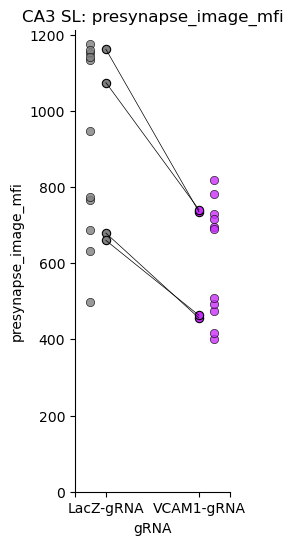

In [10]:
df_cand_gRNA = df_filtered[df_filtered["gRNA"] == "VCAM1-gRNA"]
df_LacZ_gRNA = df_filtered[df_filtered["gRNA"] == "LacZ-gRNA"]

df_average_cand_gRNA = df_averages[df_averages["gRNA"] == "VCAM1-gRNA"]
df_average_LacZ_gRNA = df_averages[df_averages["gRNA"] == "LacZ-gRNA"]

fig, ax = plt.subplots(figsize=(2, 6))

x_LacZ_points = np.ones(len(df_LacZ_gRNA)) * 0.1  
x_VCAM1_points = np.ones(len(df_cand_gRNA)) * 0.9  

x_LacZ = np.ones(len(df_average_LacZ_gRNA)) * 0.2  
x_VCAM1 = np.ones(len(df_average_cand_gRNA)) * 0.8  

plt.scatter(x_LacZ_points, df_LacZ_gRNA["presynapse_image_mfi"], color = "#808080", label="LacZ-gRNA", edgecolors= "black", alpha = 0.8, linewidths = 0.5)
plt.scatter(x_VCAM1_points, df_cand_gRNA["presynapse_image_mfi"], color = "#c92ffb", label="VCAM1-gRNA", edgecolors= "black", alpha = 0.8, linewidths = 0.5)

plt.scatter(x_LacZ, df_average_LacZ_gRNA["presynapse_image_mfi"], color = "#808080", label="LacZ-gRNA", edgecolors= "black", linewidths = 0.8)
plt.scatter(x_VCAM1, df_average_cand_gRNA["presynapse_image_mfi"], color = "#c92ffb", label="VCAM1-gRNA", edgecolors= "black", linewidths = 0.8)

for i in range(len(df_average_LacZ_gRNA)):
    plt.plot([0.2, 0.8], [df_average_LacZ_gRNA.iloc[i]["presynapse_image_mfi"], df_average_cand_gRNA.iloc[i]["presynapse_image_mfi"]], linewidth = 0.5, c='k')

plt.xticks(ticks = [0, 0.2, 0.8, 1], 
           labels = ["", 'LacZ-gRNA', "VCAM1-gRNA", ""], 
           minor = False)
plt.title("CA3 SL: presynapse_image_mfi")

plt.ylabel("presynapse_image_mfi")
plt.xlabel("gRNA")
ax.spines[['right', 'top']].set_visible(False)
plt.ylim(bottom = 0)

plt.show()

In [11]:
def create_scatter_plot_with_means(df_averages, df_points, metric, title, candidate_gRNA, control_gRNA = "LacZ-gRNA"):
    
    # individual points - preparing the data for plotting
    df_points_LacZ_gRNA = df_points[df_points["gRNA"] == control_gRNA]
    df_points_cand_gRNA = df_points[df_points["gRNA"] == candidate_gRNA]

    # mean points - preparing the data for plotting
    df_average_LacZ_gRNA = df_averages[df_averages["gRNA"] == control_gRNA]
    df_average_cand_gRNA = df_averages[df_averages["gRNA"] == candidate_gRNA]

    # set the size of the figure
    fig, ax = plt.subplots(figsize=(2, 6))
    
    # set the individual points across the x axis
    x_LacZ_points = np.ones(len(df_points_LacZ_gRNA)) * 0.1  
    x_VCAM1_points = np.ones(len(df_points_cand_gRNA)) * 0.9  

    # set the mean points across the x axis
    x_LacZ_averages = np.ones(len(df_average_LacZ_gRNA)) * 0.2  
    x_VCAM1_averages = np.ones(len(df_average_cand_gRNA)) * 0.8  

    # plot the individual points
    ax.scatter(x_LacZ_points, df_points_LacZ_gRNA[metric], color = "#808080", label = control_gRNA, edgecolors= "black", alpha = 0.6, linewidths = 0.5)
    ax.scatter(x_VCAM1_points, df_points_cand_gRNA[metric], color = "#c92ffb", label = candidate_gRNA, edgecolors= "black", alpha = 0.6, linewidths = 0.5)

    # plot the mean points
    ax.scatter(x_LacZ_averages, df_average_LacZ_gRNA[metric], color = "#808080", label = control_gRNA, edgecolors= "black", linewidths = 0.8)
    ax.scatter(x_VCAM1_averages, df_average_cand_gRNA[metric], color = "#c92ffb", label= candidate_gRNA, edgecolors= "black", linewidths = 0.8)

    # plot the lines connecting the mean points
    for i in range(len(df_average_LacZ_gRNA)):
        plt.plot([0.2, 0.8], [df_average_LacZ_gRNA.iloc[i][metric], df_average_cand_gRNA.iloc[i][metric]], linewidth = 0.5, c = "k")

    # plot the ticks
    ax.set_xticks(ticks = [0, 0.2, 0.8, 1])
    ax.set_xticklabels(["", control_gRNA, candidate_gRNA, ""])

    # other attributes
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.set_xlabel("gRNA")
    ax.spines[['right', 'top']].set_visible(False)
    ax.set_ylim(bottom = 0)

    return fig


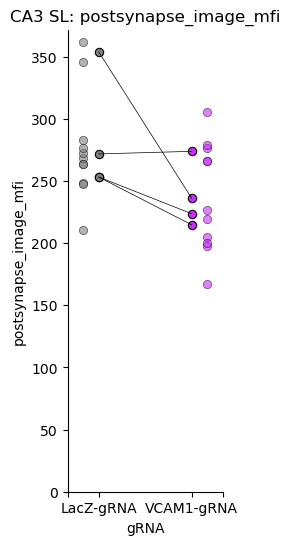

In [12]:
df_filtered , _ , df_averages , _ , p_value = check_statistics(df, hippocampal_layer = "CA3 SL", metric = "postsynapse_image_mfi", candidate_gRNA = "VCAM1-gRNA")

p = create_scatter_plot_with_means(df_averages = df_averages, df_points = df_filtered, metric = "postsynapse_image_mfi", title = "CA3 SL: postsynapse_image_mfi", candidate_gRNA = "VCAM1-gRNA")

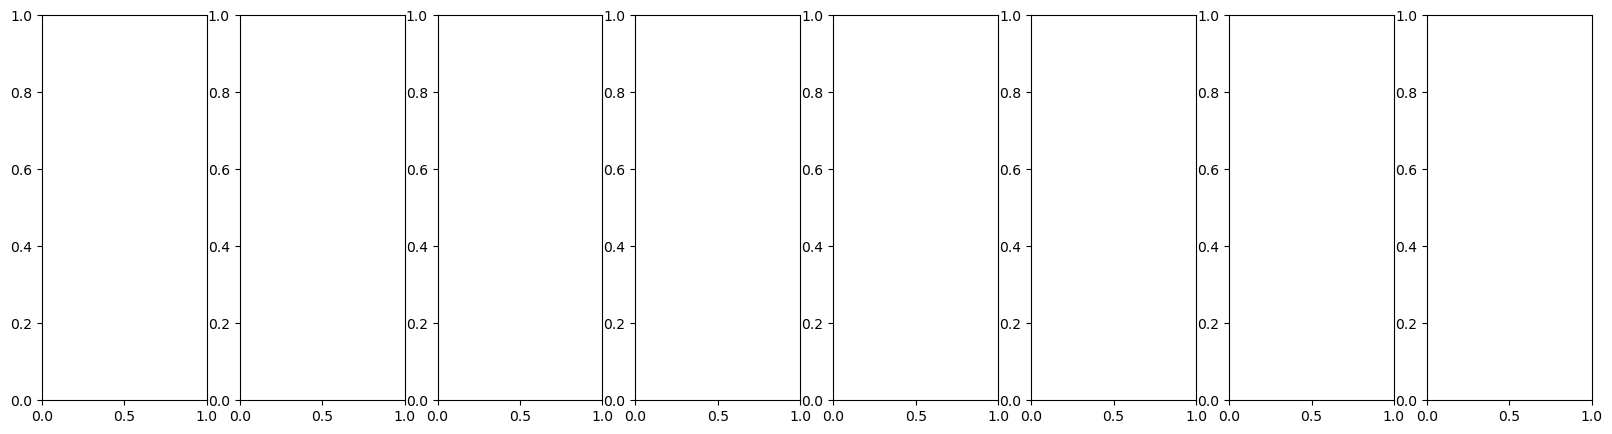

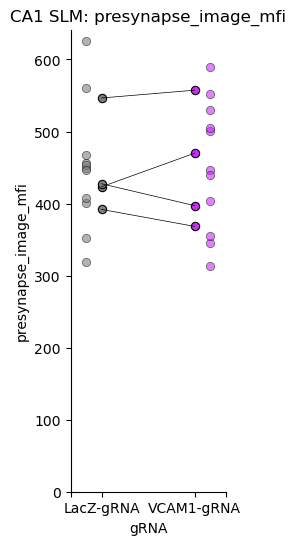

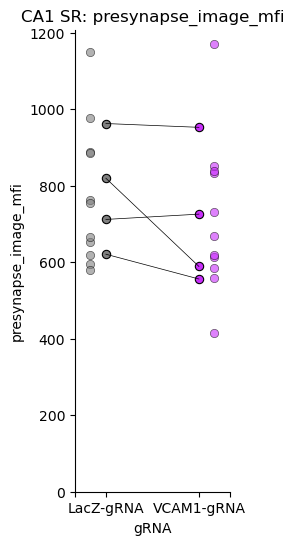

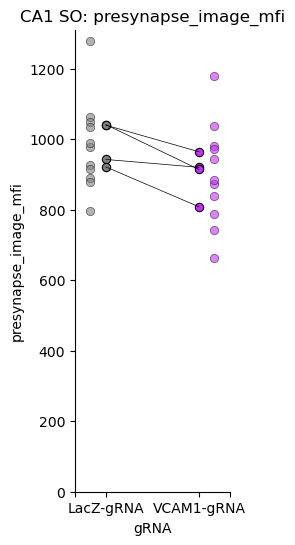

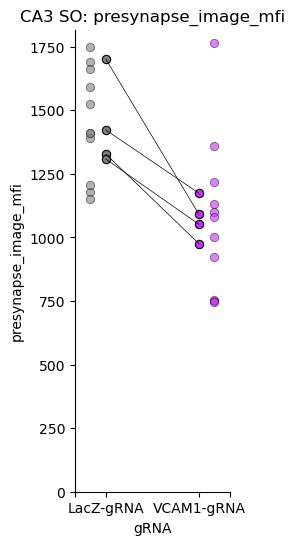

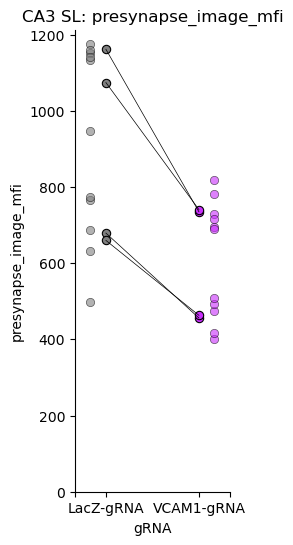

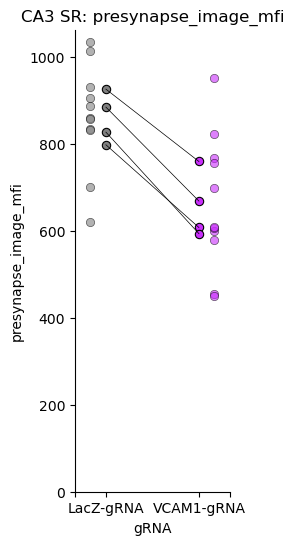

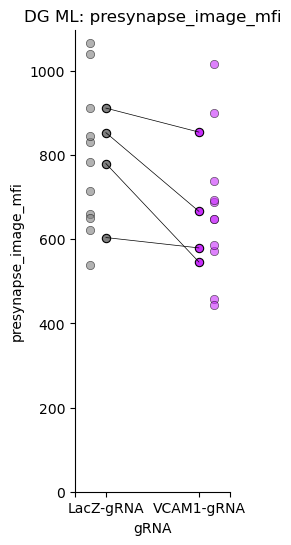

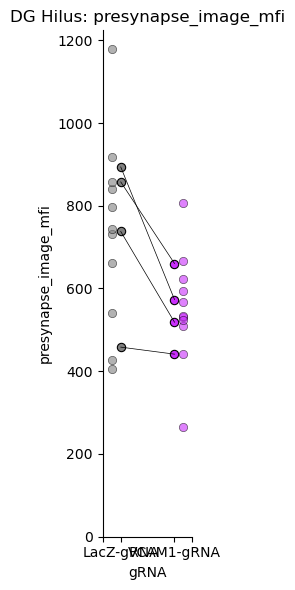

In [13]:

hippocampal_layers = ["CA1 SLM", "CA1 SR", "CA1 SO", "CA3 SO", "CA3 SL", "CA3 SR", "DG ML", "DG Hilus"]
fig, axes = plt.subplots(nrows=1, ncols= len(hippocampal_layers), figsize=(20, 5))

for idx, hippocampal_layer in enumerate(hippocampal_layers):
    # get the statistics
    df_filtered , _ , df_averages , _ , p_value = check_statistics(df, hippocampal_layer = hippocampal_layer, metric = "presynapse_image_mfi" , candidate_gRNA = "VCAM1-gRNA")
    # make the plot
    ax = axes[idx] 
    create_scatter_plot_with_means(df_averages = df_averages, df_points = df_filtered, metric = "presynapse_image_mfi", title = f"{hippocampal_layer}: presynapse_image_mfi", candidate_gRNA = "VCAM1-gRNA")
    
plt.tight_layout()



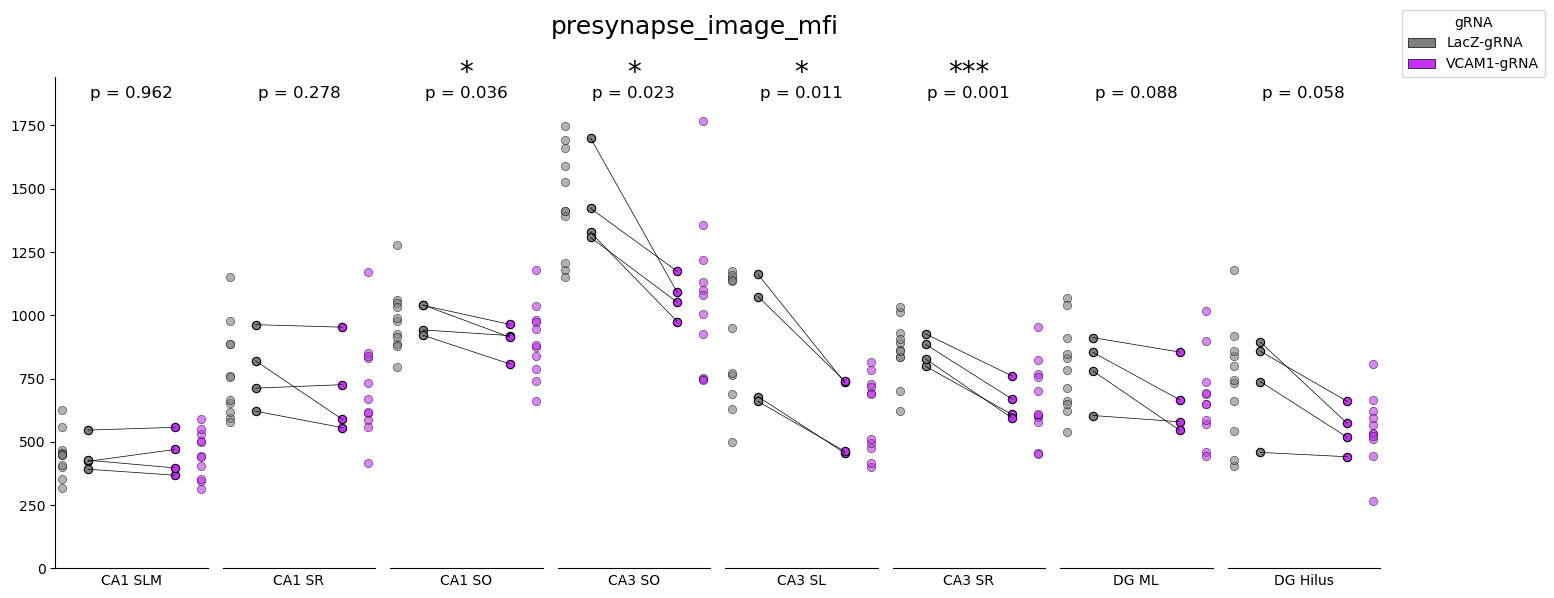

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assuming check_statistics and create_scatter_plot_with_means are defined elsewhere
# from your_module import check_statistics

# Define your DataFrame `df` here or ensure it's imported correctly
# df = pd.read_csv("your_data.csv")  # Example of loading data

hippocampal_layers = ["CA1 SLM", "CA1 SR", "CA1 SO", "CA3 SO", "CA3 SL", "CA3 SR", "DG ML", "DG Hilus"]

# set the size of the figure
fig, axes = plt.subplots(nrows = 1, ncols = len(hippocampal_layers), figsize=(14, 6))

def create_scatter_plot_with_means(ax, df_averages, df_points, metric, candidate_gRNA, control_gRNA = "LacZ-gRNA"):
    
    # individual points - preparing the data for plotting
    df_points_LacZ_gRNA = df_points[df_points["gRNA"] == control_gRNA]
    df_points_cand_gRNA = df_points[df_points["gRNA"] == candidate_gRNA]

    # mean points - preparing the data for plotting
    df_average_LacZ_gRNA = df_averages[df_averages["gRNA"] == control_gRNA]
    df_average_cand_gRNA = df_averages[df_averages["gRNA"] == candidate_gRNA]

    # set the individual points across the x axis
    x_LacZ_points = np.ones(len(df_points_LacZ_gRNA)) * 0.1  
    x_VCAM1_points = np.ones(len(df_points_cand_gRNA)) * 0.9  

    # set the mean points across the x axis
    x_LacZ_averages = np.ones(len(df_average_LacZ_gRNA)) * 0.25  
    x_VCAM1_averages = np.ones(len(df_average_cand_gRNA)) * 0.75 

    # plot the individual points
    ax.scatter(x_LacZ_points, df_points_LacZ_gRNA[metric], color = "#808080", edgecolors = "black", alpha = 0.6, linewidths = 0.5)
    ax.scatter(x_VCAM1_points, df_points_cand_gRNA[metric], color = "#c92ffb", edgecolors = "black", alpha = 0.6, linewidths = 0.5)

    # plot the mean points
    ax.scatter(x_LacZ_averages, df_average_LacZ_gRNA[metric], color = "#808080", edgecolors = "black", linewidths = 0.8)
    ax.scatter(x_VCAM1_averages, df_average_cand_gRNA[metric], color = "#c92ffb", edgecolors = "black", linewidths = 0.8)

    # plot the lines connecting the mean points
    for i in range(len(df_average_LacZ_gRNA)):
        ax.plot([0.25, 0.75], [df_average_LacZ_gRNA.iloc[i][metric], df_average_cand_gRNA.iloc[i][metric]], linewidth = 0.5, c = "k")

    # other attributes
    ax.spines[['right', 'top']].set_visible(False)

# variables to track the global y-axis limits
global_y_max = float('-inf')

for idx, hippocampal_layer in enumerate(hippocampal_layers):
    # get statistics
    df_filtered, _, df_averages, _, p_value = check_statistics(df, hippocampal_layer=hippocampal_layer, metric="presynapse_image_mfi", candidate_gRNA="VCAM1-gRNA")
    
    # update global y-axis limits
    local_y_max = max(df_filtered["presynapse_image_mfi"].max(), df_averages["presynapse_image_mfi"].max())
    global_y_max = max(global_y_max, local_y_max)
    
    # make the plot on the specific subplot axis
    ax

    # make the plot on the specific subplot axis
    ax = axes[idx]
    create_scatter_plot_with_means(ax, df_averages, df_filtered, metric="presynapse_image_mfi", candidate_gRNA="VCAM1-gRNA")

    # set x-axis labels to hippocampal layer names
    ax.set_xlabel(f"{hippocampal_layer}")

    # remove x-tick labels
    ax.set_xticks([])

    # remove y-axis labels and y axis lines for all but the first plot
    if idx > 0:
        ax.set_ylabel("")
        ax.set_yticks([])
        ax.spines['left'].set_visible(False)

    # add p-value to each graph
    p_value_str = f"p = {p_value:.3f}"
    p_value_text = ax.text(0.5, 0.95, p_value_str, ha = 'center', va='bottom', transform=ax.transAxes, fontsize=12)  # Font size for p-value

    # add significant stars as a separate text object with a larger font size
    stars = ""
    if p_value < 0.0001:
        stars = "****"
    elif p_value < 0.001:
        stars = "***"
    elif p_value < 0.01:
        stars = "**"
    elif p_value < 0.05:
        stars = "*"
    stars_text = ax.text(0.5, 0.98, stars, ha='center', va='bottom', transform=ax.transAxes, fontsize=20)  # Larger font size for stars

# apply global y-axis limits to all subplots
global_y_max = global_y_max * 1.1  # adjust the maximum y-axis to be 0.1 higher
for ax in axes:
    ax.set_ylim(0, global_y_max)

# create a color-coded legend outside the loop with patch objects for color matching
handles = [
    plt.Rectangle((0, 0), 1, 1, color="#808080", ec="black", lw=0.5),
    plt.Rectangle((0, 0), 1, 1, color="#c92ffb", ec="black", lw=0.5),
]
labels = ["LacZ-gRNA", "VCAM1-gRNA"]
fig.legend(handles, labels, loc='upper left', title="gRNA", bbox_to_anchor=(1, 1))  # Adjust x and y coordinates as needed

# Add a title to the figure
fig.suptitle("presynapse_image_mfi", fontsize=18)

plt.tight_layout()
plt.show()  # Or plt.savefig("output.png") to save the figure

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import io
from PIL import Image
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas



def create_scatter_plot_with_means(ax, df_averages, df_points, metric, candidate_gRNA, control_gRNA = "LacZ-gRNA"):
    
    # individual points - preparing the data for plotting
    df_points_LacZ_gRNA = df_points[df_points["gRNA"] == control_gRNA]
    df_points_cand_gRNA = df_points[df_points["gRNA"] == candidate_gRNA]

    # mean points - preparing the data for plotting
    df_average_LacZ_gRNA = df_averages[df_averages["gRNA"] == control_gRNA]
    df_average_cand_gRNA = df_averages[df_averages["gRNA"] == candidate_gRNA]

    # set the individual points across the x axis
    x_LacZ_points = np.ones(len(df_points_LacZ_gRNA)) * 0.1  
    x_VCAM1_points = np.ones(len(df_points_cand_gRNA)) * 0.9  

    # set the mean points across the x axis
    x_LacZ_averages = np.ones(len(df_average_LacZ_gRNA)) * 0.25  
    x_VCAM1_averages = np.ones(len(df_average_cand_gRNA)) * 0.75 

    # plot the individual points
    ax.scatter(x_LacZ_points, df_points_LacZ_gRNA[metric], color = "#808080", edgecolors = "black", alpha = 0.6, linewidths = 0.5)
    ax.scatter(x_VCAM1_points, df_points_cand_gRNA[metric], color = "#c92ffb", edgecolors = "black", alpha = 0.6, linewidths = 0.5)

    # plot the mean points
    ax.scatter(x_LacZ_averages, df_average_LacZ_gRNA[metric], color = "#808080", edgecolors = "black", linewidths = 0.8)
    ax.scatter(x_VCAM1_averages, df_average_cand_gRNA[metric], color = "#c92ffb", edgecolors = "black", linewidths = 0.8)

    # plot the lines connecting the mean points
    for i in range(len(df_average_LacZ_gRNA)):
        ax.plot([0.25, 0.75], [df_average_LacZ_gRNA.iloc[i][metric], df_average_cand_gRNA.iloc[i][metric]], linewidth = 0.5, c = "k")

    # other attributes
    ax.spines[['right', 'top']].set_visible(False)



def create_scatter_plot_with_means_per_hippocampal_layer(hippocampal_layer_list, df_averages, df_filtered, metric, candidate_gRNA, control_gRNA = "LacZ-gRNA", ax = None):
    
    # set the size of the figure
    if ax is None:
        fig, axes = plt.subplots(nrows = 1, ncols = len(hippocampal_layer_list), figsize=(12, 6))

    # variables to track the global y-axis limits
    global_y_max = float('-inf')

    for idx, hippocampal_layer in enumerate(hippocampal_layer_list):
        
        # get statistics
        df_filtered, _, df_averages, _, p_value = check_statistics(df, hippocampal_layer = hippocampal_layer, metric= metric, candidate_gRNA = candidate_gRNA)
        
        # update global y-axis limits
        local_y_max = max(df_filtered[metric].max(), df_averages[metric].max())
        global_y_max = max(global_y_max, local_y_max)
        
        # make the plot on the specific subplot axis
        ax

        # make the plot on the specific subplot axis
        ax = axes[idx]
        create_scatter_plot_with_means(ax, df_averages = df_averages, df_points = df_filtered, metric = metric, candidate_gRNA = candidate_gRNA)

        # set x-axis labels to hippocampal layer names
        ax.set_xlabel(f"{hippocampal_layer}")

        # remove x-tick labels
        ax.set_xticks([])

        # remove y-axis labels and y axis lines for all but the first plot
        if idx > 0:
            ax.set_ylabel("")
            ax.set_yticks([])
            ax.spines['left'].set_visible(False)

        # add p-value to each graph
        p_value_str = f"p = {p_value:.3f}"
        p_value_text = ax.text(0.5, 0.95, p_value_str, ha = 'center', va='bottom', transform=ax.transAxes, fontsize=12)  # Font size for p-value

        # add significant stars as a separate text object with a larger font size
        stars = ""
        if p_value < 0.0001:
            stars = "****"
        elif p_value < 0.001:
            stars = "***"
        elif p_value < 0.01:
            stars = "**"
        elif p_value < 0.05:
            stars = "*"
        stars_text = ax.text(0.5, 0.98, stars, ha='center', va='bottom', transform=ax.transAxes, fontsize=20)  # Larger font size for stars

    # apply global y-axis limits to all subplots
    global_y_max = global_y_max * 1.1  # adjust the maximum y-axis to be 0.1 higher
    for ax in axes:
        ax.set_ylim(0, global_y_max)

    # create a color-coded legend outside the loop with patch objects for color matching
    handles = [
        plt.Rectangle((0, 0), 1, 1, color="#808080", ec="black", lw=0.5),
        plt.Rectangle((0, 0), 1, 1, color="#c92ffb", ec="black", lw=0.5),
    ]
    labels = [control_gRNA, candidate_gRNA]
    fig.legend(handles, labels, loc='upper left', title="gRNA", bbox_to_anchor=(1, 1))  # Adjust x and y coordinates as needed

    # Add a title to the figure
    fig.suptitle(metric, fontsize=18)

    plt.tight_layout()

    return fig

# saves an image into buffer memory, way around the axes from matplotlib because its already used to create a single
def save_plot_to_bytes(fig):
    buf = io.BytesIO()
    canvas = FigureCanvas(fig)
    canvas.print_png(buf)
    buf.seek(0)
    return Image.open(buf)

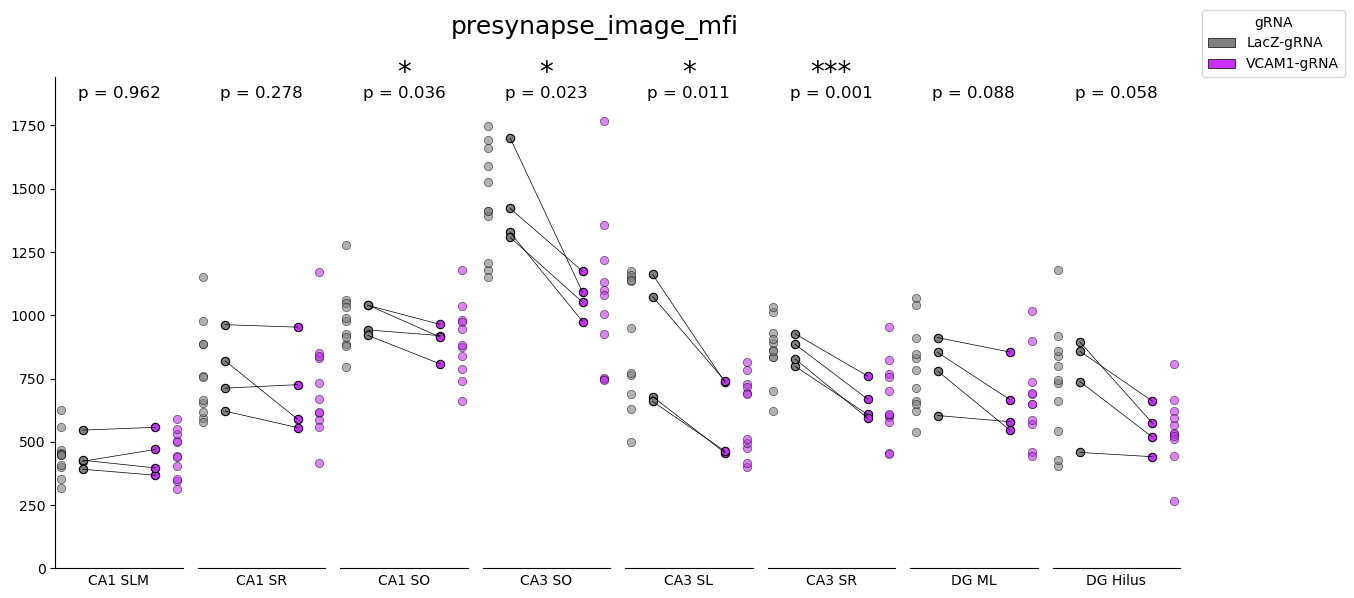

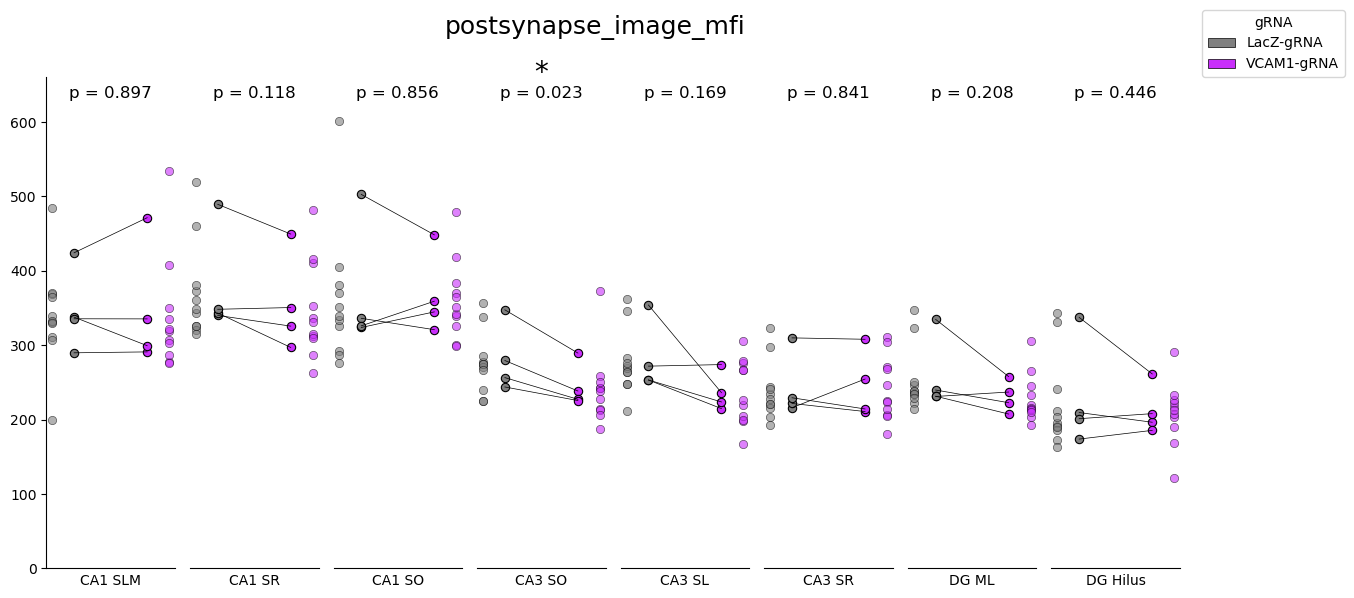

In [27]:
hippocampal_layers = ["CA1 SLM", "CA1 SR", "CA1 SO", "CA3 SO", "CA3 SL", "CA3 SR", "DG ML", "DG Hilus"]
metrics = ["overlap_um2", "pearson_cor", "overlap_coeff", "presynapse_image_mfi", "postsynapse_image_mfi", "pre_puncta_density_per_100_um2", "post_puncta_density_per_100_um2", "pre_staining_area_um2", "post_staining_area_um2", "pre_mean_puncta_size_um2", "post_mean_puncta_size_um2"]


# Call the function for each metric
plot_presynapse_image_mfi = create_scatter_plot_with_means_per_hippocampal_layer(hippocampal_layer_list = hippocampal_layers, df_averages = df_averages, df_filtered = df_filtered, metric = "presynapse_image_mfi", candidate_gRNA = "VCAM1-gRNA")
plot_postsynapse_image_mfi = create_scatter_plot_with_means_per_hippocampal_layer(hippocampal_layer_list = hippocampal_layers, df_averages = df_averages , df_filtered = df_filtered, metric = "postsynapse_image_mfi", candidate_gRNA = "VCAM1-gRNA")


In [34]:
hippocampal_layers = ["CA1 SLM", "CA1 SR", "CA1 SO", "CA3 SO", "CA3 SL", "CA3 SR", "DG ML", "DG Hilus"]
metrics = ["overlap_um2", "pearson_cor", "overlap_coeff", "presynapse_image_mfi", "postsynapse_image_mfi", "pre_puncta_density_per_100_um2", "post_puncta_density_per_100_um2", "pre_staining_area_um2", "post_staining_area_um2", "pre_mean_puncta_size_um2", "post_mean_puncta_size_um2"]

# loops over the images
images = []
for metric in metrics:
    fig = create_scatter_plot_with_means_per_hippocampal_layer(hippocampal_layers, df_averages, df_filtered, metric, candidate_gRNA="VCAM1-gRNA")
    image = save_plot_to_bytes(fig)
    images.append(image)
    plt.close(fig) # do not print out each figure

# extracts figure dimensions
widths, heights = zip(*(img.size for img in images))
total_height = sum(heights)
max_width = max(widths)

# combines the figures and pastes it into the blank canvas
combined_image = Image.new('RGB', (max_width, total_height))
y_offset = 0
for img in images:
    combined_image.paste(img, (0, y_offset))
    y_offset += img.height

# saves the image
combined_image.save("combined_plot.png")


(0.0, 127.22781003348837)

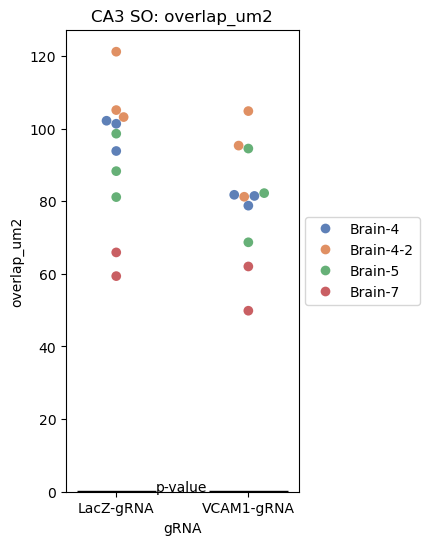

In [54]:
fig, ax = plt.subplots(figsize=(3, 6))

sns.swarmplot(x="gRNA", y="overlap_um2", hue="Brain", alpha=0.9, size= 7, palette="deep", data=df_filtered)

# line as mean
mean = table.mean()
for i, m in enumerate(mean):
    plt.hlines(m, i - 0.3, i + 0.3, color='black', linewidth=1)

plt.text(0.3, 0.2, "p-value")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title("CA3 SO: overlap_um2")
plt.ylim(bottom = 0)

In [97]:
def plot_significant_data(df_filtered, metric, title, p_value):
    
    fig, ax = plt.subplots(figsize=(3, 6))
    p = sns.swarmplot(x="gRNA", y=metric, hue="Brain", alpha=0.9, size= 7, palette="deep", data=df_filtered)
    
    mean = table.mean()
    for i, m in enumerate(mean):
        plt.hlines(m, i - 0.3, i + 0.3, color='black', linewidth=1)
    p_value = round(p_value, 4)
    p.text(0.2, 0.0715, f"p-val = {p_value}")
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    p.set_title(title)
    p.set_ylim(bottom = 0)
    
    return p

<Axes: title={'center': 'CA3 SO: postsynapse puncta size'}, xlabel='gRNA', ylabel='post_mean_puncta_size_um2'>

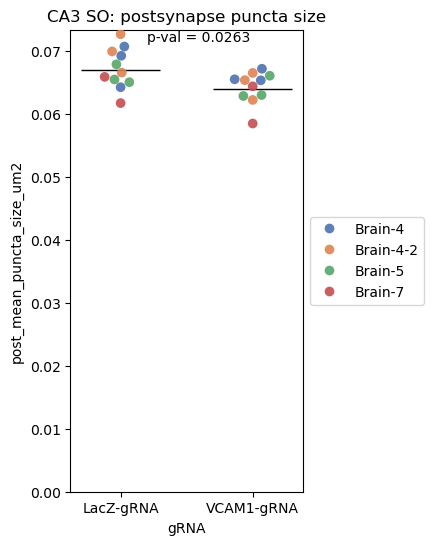

In [98]:
plot_significant_data(df_filtered = df_filtered, metric = "post_mean_puncta_size_um2", p_value = p_value, title = "CA3 SO: postsynapse puncta size")

In [7]:
filtered_df_CA3_SL = df[df['hippocampal_layer'].str.contains('CA3 SL')]

In [10]:
# statistics and getting into the right format - CA3 SL
ReplicateAverages = filtered_df_CA3_SL.groupby(["gRNA","Brain"], as_index=False).agg({"presynapse_image_mfi":"mean"})
ReplicateAverages.head(5)
ReplicateAvePivot = ReplicateAverages.pivot_table(columns="gRNA", values="presynapse_image_mfi", index="Brain")
ReplicateAvePivot.head(10)

gRNA,LacZ-gRNA,VCAM1-gRNA
Brain,,
Brain-4,1161.365756,734.770922
Brain-4-2,678.876933,455.993738
Brain-5,1074.041745,740.594560
Brain-7,659.677138,463.068465


In [11]:
statistic, pvalue = scipy.stats.ttest_rel(ReplicateAvePivot["LacZ-gRNA"], ReplicateAvePivot["VCAM1-gRNA"])
print("pvalue:", pvalue, "\n" "& t-statistic:", statistic)
mean = ReplicateAvePivot.mean()
print(mean)
sem = ReplicateAvePivot.sem()
print(sem)

pvalue: 0.011440825772768679 
& t-statistic: 5.566397728654104
gRNA
LacZ-gRNA     893.490393
VCAM1-gRNA    598.606921
dtype: float64
gRNA
LacZ-gRNA     130.729867
VCAM1-gRNA     80.317245
dtype: float64
